In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

dt = {"col1":[51,22,13,64,50,np.nan,17,580,19,1000],
      "col2":[np.nan,np.nan,89,np.nan,76,np.nan,53,np.nan,900,np.nan],
      "col3":['male','male','male','male','male','male','male',np.nan,'female',np.nan],
      "col4":['good','bad','good',np.nan,'good','bad','bad',np.nan,'good',np.nan]}

df = pd.DataFrame(dt)

df

,col1,col2,col3,col4
0,51.0,NaN,male,good
1,22.0,NaN,male,bad
2,13.0,89.0,male,good
3,64.0,NaN,male,NaN
4,50.0,76.0,male,good
5,NaN,NaN,male,bad
6,17.0,53.0,male,bad
7,580.0,NaN,NaN,NaN
8,19.0,900.0,female,good
9,1000.0,NaN,NaN,NaN


In [ ]:
df.isna().sum()

,0
col1,1
col2,6
col3,2
col4,3


In [ ]:
df.isna().sum().sort_values()

,0
col1,1
col3,2
col4,3
col2,6


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
col2,6
col4,3
col3,2
col1,1


In [ ]:
df.isna().sum(axis=1).sort_values()

,0
2,0
4,0
6,0
8,0
1,1
0,1
5,2
3,2
7,3
9,3


In [ ]:
df.isna().sum(axis=1).sort_values(ascending=False)

,0
7,3
9,3
3,2
5,2
1,1
0,1
4,0
2,0
6,0
8,0


In [ ]:
df.isna().sum(axis=1)

,0
0,1
1,1
2,0
3,2
4,0
5,2
6,0
7,3
8,0
9,3


In [ ]:
df

,col1,col2,col3,col4
0,51.0,NaN,male,good
1,22.0,NaN,male,bad
2,13.0,89.0,male,good
3,64.0,NaN,male,NaN
4,50.0,76.0,male,good
5,NaN,NaN,male,bad
6,17.0,53.0,male,bad
7,580.0,NaN,NaN,NaN
8,19.0,900.0,female,good
9,1000.0,NaN,NaN,NaN


In [ ]:
# Drop columns
threshold=0.5
df=df[df.columns[df.isnull().mean()<threshold]]
df


,col1,col3,col4
0,51.0,male,good
1,22.0,male,bad
2,13.0,male,good
3,64.0,male,NaN
4,50.0,male,good
5,NaN,male,bad
6,17.0,male,bad
7,580.0,NaN,NaN
8,19.0,female,good
9,1000.0,NaN,NaN


In [ ]:
# Drop columns
threshold=0.5
df=df.loc[df.isnull().mean(axis=1)<threshold]
df

,col1,col3,col4
0,51.0,male,good
1,22.0,male,bad
2,13.0,male,good
3,64.0,male,NaN
4,50.0,male,good
5,NaN,male,bad
6,17.0,male,bad
8,19.0,female,good


In [ ]:
# Print mean, median and mode for col1
print(f"Mean of col1: {df['col1'].mean()}")
print(f"Median of col1: {df['col1'].median()}")
print(f"Mode of col1: {df['col1'].mode()}")

Mean of col1: 33.714285714285715
Median of col1: 22.0
Mode of col1: 0    13.0
1    17.0
2    19.0
3    22.0
4    50.0
5    51.0
6    64.0
Name: col1, dtype: float64


In [ ]:
# Print mean, median and mode for col1
print(f"Mean of col1: {df['col1'].mean()}")
print(f"Median of col1: {df['col1'].median()}")
print(f"Mode of col1: {df['col1'].mode().iloc[0]}")

Mean of col1: 33.714285714285715
Median of col1: 22.0
Mode of col1: 13.0


In [ ]:
num_cols = ['col1']
num_cols

['col1']

In [ ]:
# it does not change df permanently, just replaced
df[num_cols].fillna(0)

,col1
0,51.0
1,22.0
2,13.0
3,64.0
4,50.0
5,0.0
6,17.0
8,19.0


In [ ]:
# if you update the original df permanently
# df[num_cols] = df[num_cols].fillna(0)


In [ ]:
df['col1'].fillna(df['col1'].mean())

,col1
0,51.000000
1,22.000000
2,13.000000
3,64.000000
4,50.000000
5,33.714286
6,17.000000
8,19.000000


In [ ]:
df[num_cols].fillna(df[num_cols].mean())


,col1
0,51.000000
1,22.000000
2,13.000000
3,64.000000
4,50.000000
5,33.714286
6,17.000000
8,19.000000


In [ ]:
df[num_cols].fillna(df[num_cols].median())

,col1
0,51.0
1,22.0
2,13.0
3,64.0
4,50.0
5,22.0
6,17.0
8,19.0


In [ ]:
df['col1'].fillna(df['col1'].median())

,col1
0,51.0
1,22.0
2,13.0
3,64.0
4,50.0
5,22.0
6,17.0
8,19.0


In [ ]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df

,col1,col3,col4
0,51.0,male,good
1,22.0,male,bad
2,13.0,male,good
3,64.0,male,NaN
4,50.0,male,good
5,22.0,male,bad
6,17.0,male,bad
8,19.0,female,good


In [ ]:
cat_cols = ['col3', 'col4']

In [ ]:
# Max fill function for categorical columns
df['col3'].fillna(df['col3'].value_counts().idxmax())

,col3
0,male
1,male
2,male
3,male
4,male
5,male
6,male
8,female


In [ ]:
# Fill all categorical columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].value_counts().idxmax())

df

,col1,col3,col4
0,51.0,male,good
1,22.0,male,bad
2,13.0,male,good
3,64.0,male,good
4,50.0,male,good
5,22.0,male,bad
6,17.0,male,bad
8,19.0,female,good


In [ ]:
print(f"Mean of col1: {df['col1'].mean()}")

Mean of col1: 32.25


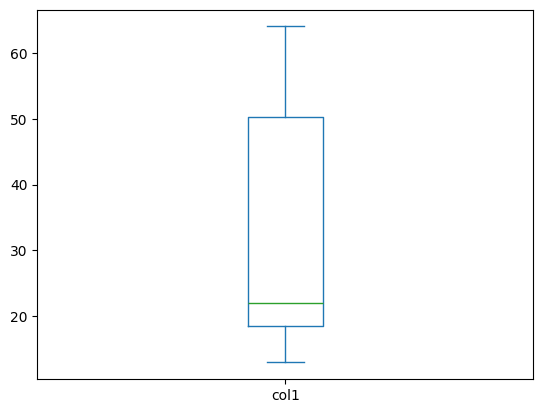

In [ ]:
df.plot.box();

In [ ]:
def detect_outlier(feature):
    Q1 = feature.quantile(0.25)
    Q3 = feature.quantile(0.75)

    IQR = Q3-Q1

    lower_bound = Q1-(1.5*IQR)
    upper_bound = Q3-(1.5*IQR)

    return feature.index[(feature<lower_bound)|(feature>upper_bound)].tolist()

In [ ]:
for col in num_cols:
    print(col,'-->',detect_outlier(df[col]))

col1 --> []


In [ ]:
for col in num_cols:
    indx = detect_outlier(df[col])
    df[col].loc[indx] = df[col].median()

In [ ]:
df

,col1,col3,col4
0,51.0,male,good
1,22.0,male,bad
2,13.0,male,good
3,64.0,male,good
4,50.0,male,good
5,22.0,male,bad
6,17.0,male,bad
8,19.0,female,good


In [ ]:
for col in num_cols:
    indx = detect_outlier(df[col])
    df[col].loc[indx] = np.nan

df.dropna(inplace=True) # drops any row that contains at least one NaN and modifies the DataFrame directly

In [ ]:
import pandas as pd

dfe = pd.DataFrame({
    'Name': ['Abid', 'Sara', 'John', 'Mina'],
    'Age': [22, 35, 28, 40],
    'Country': ['Bangladesh', 'USA', 'UK', 'Canada']
})


In [ ]:
dfe

,Name,Age,Country
0,Abid,22,Bangladesh
1,Sara,35,USA
2,John,28,UK
3,Mina,40,Canada


In [ ]:
# select row only
dfe.loc[2]

,2
Name,John
Age,28
Country,UK


In [ ]:
# select row 1 and 3
df.loc[[1,3]]

,col1,col3,col4
1,22.0,male,bad
3,64.0,male,good


In [ ]:
# select all rows form 'age' column
dfe.loc[:, 'Age']

,Age
0,22
1,35
2,28
3,40


In [ ]:
# All rows, selected columns
dfe.loc[:, ['Name','Country']]


,Name,Country
0,Abid,Bangladesh
1,Sara,USA
2,John,UK
3,Mina,Canada


In [ ]:
# Selecting rows AND columns
dfe.loc[[1,3], ['Name','Country']]

,Name,Country
1,Sara,USA
3,Mina,Canada


In [ ]:
# Conditional row selection
dfe.loc[dfe['Age'] > 30, ['Name','Country']]

,Name,Country
1,Sara,USA
3,Mina,Canada


In [ ]:
# update a single value
dfe.loc[0, 'Age'] = 23

In [ ]:
dfe

,Name,Age,Country
0,Abid,23.0,Bangladesh
1,Sara,50.0,USA
2,John,28.0,UK
3,Mina,NaN,Canada


In [ ]:
dfe.loc[[0,1],'Age']=50

In [ ]:
dfe

,Name,Age,Country
0,Abid,50.0,Bangladesh
1,Sara,50.0,USA
2,John,28.0,UK
3,Mina,NaN,Canada


In [ ]:
# update multiple rows
dfe.loc[dfe['Country'] == 'USA', 'Age'] = 36

In [ ]:
# Mark outliers as NaN
dfe.loc[[3], 'Age'] = np.nan

In [ ]:
dfe

,Name,Age,Country
0,Abid,23.0,Bangladesh
1,Sara,36.0,USA
2,John,28.0,UK
3,Mina,NaN,Canada


In [ ]:
for col in cat_cols:
    df[col] = df[col].astype('category')
    print(col,'---->', dict(enumerate(df[col].cat.categories)))
    df[col] = df[col].cat.codes

col3 ----> {0: 'female', 1: 'male'}
col4 ----> {0: 'bad', 1: 'good'}


In [ ]:
df

,col1,col3,col4
0,51.0,1,1
1,22.0,1,0
2,13.0,1,1
3,64.0,1,1
4,50.0,1,1
5,22.0,1,0
6,17.0,1,0
8,19.0,0,1


In [ ]:
import pandas as pd

df1 = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Female', 'Male'],
    'City': ['Dhaka', 'London', 'Dhaka', 'Paris']
})

cat_cols = ['Gender', 'City']


In [ ]:
df1

,Gender,City
0,Male,Dhaka
1,Female,London
2,Female,Dhaka
3,Male,Paris


In [ ]:
for col in cat_cols:
    df1[col] = df1[col].astype('category')
    print(col,'---->', dict(enumerate(df1[col].cat.categories)))
    df1[col] = df1[col].cat.codes


Gender ----> {0: 'Female', 1: 'Male'}
City ----> {0: 'Dhaka', 1: 'London', 2: 'Paris'}


In [ ]:
df1

,Gender,City
0,1,0
1,0,1
2,0,0
3,1,2


In [ ]:
df1 = pd.get_dummies(df1, columns=cat_cols, prefix=cat_cols)

df1

,Gender_0,Gender_1,City_0,City_1,City_2
0,False,True,True,False,False
1,True,False,False,True,False
2,True,False,True,False,False
3,False,True,False,False,True


In [ ]:
!pip install scikit-learn

In [ ]:
from imblearn.datasets import make_imbalance
from sklearn.datasets import load_iris

data = load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
data.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
data.data_module

'sklearn.datasets.data'

In [ ]:
data.DESCR

'.. _iris_dataset:\n\nIris plants dataset\n--------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 150 (50 in each of three classes)\n:Number of Attributes: 4 numeric, predictive attributes and the class\n:Attribute Information:\n    - sepal length in cm\n    - sepal width in cm\n    - petal length in cm\n    - petal width in cm\n    - class:\n            - Iris-Setosa\n            - Iris-Versicolour\n            - Iris-Virginica\n\n:Summary Statistics:\n\n============== ==== ==== ======= ===== ====================\n                Min  Max   Mean    SD   Class Correlation\n============== ==== ==== ======= ===== ====================\nsepal length:   4.3  7.9   5.84   0.83    0.7826\nsepal width:    2.0  4.4   3.05   0.43   -0.4194\npetal length:   1.0  6.9   3.76   1.76    0.9490  (high!)\npetal width:    0.1  2.5   1.20   0.76    0.9565  (high!)\n============== ==== ==== ======= ===== ====================\n\n:Missing Attribute Values: None\n:Class Distribution: 

In [ ]:
data.filename

'iris.csv'

Data shape: (60,)
Data shape: (60, 4)


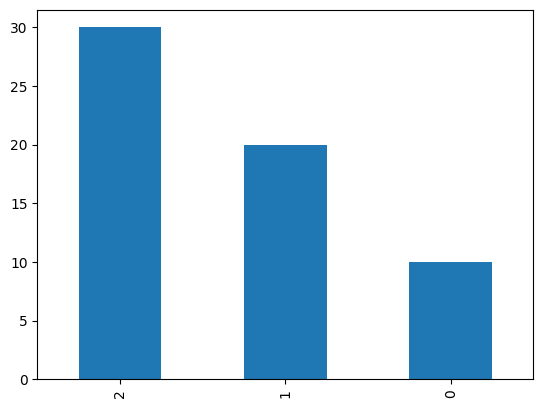

In [ ]:
from imblearn.datasets import make_imbalance
from sklearn.datasets import load_iris

data = load_iris()
X, y = data.data, data.target
X, y = make_imbalance(X, y, sampling_strategy={0: 10, 1: 20, 2: 30}, random_state=42)

print("Data shape:", y.shape)
print('Data shape:',X.shape)
pd.Series(y).value_counts().plot.bar();

Data shape: (90,)


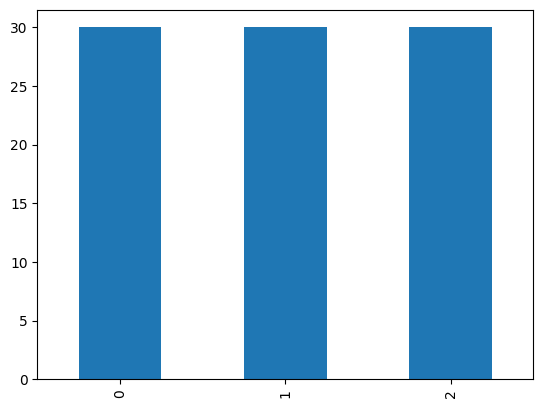

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_smt, y_smt = sm.fit_resample(X, y)

print("Data shape:", y_smt.shape)
pd.Series(y_smt).value_counts().plot.bar();

Data shape: (30,)


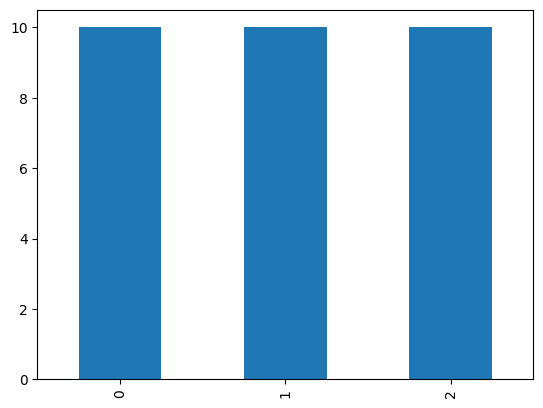

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

print("Data shape:", y_rus.shape)
pd.Series(y_rus).value_counts().plot.bar();

In [ ]:
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import minmax_scale

# set seed for reproducibility
np.random.seed(10)

# generate 1000 data points randomly drawn from an exponential distr
original_data = np.random.exponential(size = 1000)

In [ ]:
original_data

array([1.47543445e+00, 2.09702971e-02, 1.00416130e+00, 1.38152130e+00,
       6.90165654e-01, 2.54629891e-01, 2.20725059e-01, 1.42933011e+00,
       1.85258870e-01, 9.24879616e-02, 1.15632557e+00, 3.06601196e+00,
       3.95608131e-03, 7.17833933e-01, 1.67462177e+00, 9.48106702e-01,
       1.27925440e+00, 3.45136156e-01, 2.49828522e+00, 1.25377873e+00,
       7.82075378e-01, 1.53349390e-01, 4.67352363e-01, 1.12126784e+00,
       5.83097391e-01, 5.69185924e-01, 9.61724852e-01, 7.19775062e-01,
       1.05095757e+00, 9.18891494e-01, 1.63590098e+00, 7.37406644e-01,
       2.39304474e+00, 3.84539713e-01, 9.48155863e-02, 3.57675525e-01,
       1.21020678e-01, 1.76422987e+00, 4.80315873e-02, 9.84267553e-01,
       7.93157934e-01, 1.71084512e+00, 2.21828841e-01, 1.94386436e+00,
       4.33328676e-01, 1.40506011e+00, 3.50922531e-01, 2.15361765e+00,
       3.93800857e-01, 1.80342593e-01, 4.98451243e-01, 9.81205372e-02,
       1.72095991e+00, 1.63875166e-01, 4.84694126e-01, 2.88707003e+00,
      

In [ ]:
# mix-max scale the data betYouen 0 and 1
scaled_data = minmax_scale(original_data)

In [ ]:
scaled_data

array([2.23356358e-01, 2.91141485e-03, 1.51928141e-01, 2.09122472e-01,
       1.04337588e-01, 3.83258842e-02, 3.31871197e-02, 2.16368583e-01,
       2.78117091e-02, 1.37509447e-02, 1.74990823e-01, 4.64431239e-01,
       3.32665940e-04, 1.08531113e-01, 2.53546060e-01, 1.43432261e-01,
       1.93622453e-01, 5.20434093e-02, 3.78384092e-01, 1.89761249e-01,
       1.18267828e-01, 2.29753688e-02, 7.05670319e-02, 1.69677320e-01,
       8.81098542e-02, 8.60013715e-02, 1.45496287e-01, 1.08825319e-01,
       1.59020789e-01, 1.39004276e-01, 2.47677367e-01, 1.11497639e-01,
       3.62433386e-01, 5.80155846e-02, 1.41037297e-02, 5.39439309e-02,
       1.80754879e-02, 2.67127455e-01, 7.01294228e-03, 1.48912957e-01,
       1.19947548e-01, 2.59036229e-01, 3.33544136e-02, 2.94353644e-01,
       6.54102531e-02, 2.12690116e-01, 5.29204176e-02, 3.26144769e-01,
       5.94192442e-02, 2.70665767e-02, 7.52805140e-02, 1.46046425e-02,
       2.60569272e-01, 2.45707014e-02, 7.31954253e-02, 4.37310019e-01,
      

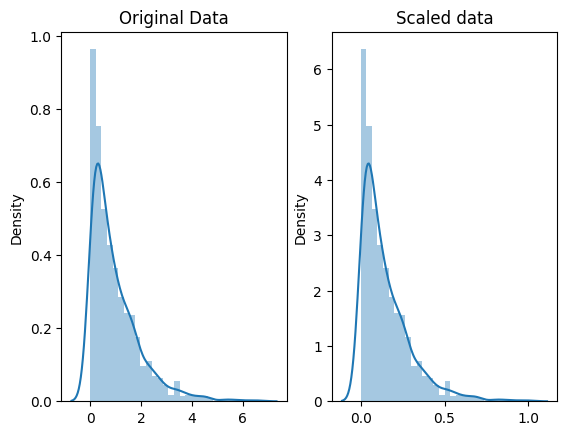

In [ ]:
# plot both together to compare
fig, ax=plt.subplots(1,2)

sns.distplot(original_data, ax=ax[0])
ax[0].set_title("Original Data")

sns.distplot(scaled_data, ax=ax[1])
ax[1].set_title("Scaled data")
plt.show()

In [ ]:
# for Box-Cox Transformation
from scipy import stats

# normalize the exponential data with boxcox
normalized_data = stats.boxcox(original_data)

In [ ]:
normalized_data

(array([ 0.410208  , -2.39448983,  0.00415501,  0.33777201, -0.35278639,
        -1.14286538, -1.23958205,  0.37508096, -1.3531397 , -1.75394085,
         0.14814612,  1.30922806, -2.86485595, -0.31705045,  0.55337562,
        -0.05290501,  0.25468836, -0.9241054 ,  1.03930996,  0.23324203,
        -0.23779006, -1.46978663, -0.68733683,  0.11625514, -0.50180215,
        -0.52259483, -0.03882107, -0.31458126,  0.05003821, -0.08362436,
         0.52655625, -0.29237244,  0.9844615 , -0.84189256, -1.74086477,
        -0.89723245, -1.60769337,  0.61375153, -2.06869014, -0.01582347,
        -0.22460114,  0.57805906, -1.23626854,  0.72835552, -0.74820749,
         0.35625679, -0.91161779,  0.85278944, -0.82346871, -1.37010327,
        -0.63446304, -1.72269436,  0.58488341, -1.4295017 , -0.65754717,
         1.22840092,  1.82081662, -0.46350581,  0.60392044, -1.05270331,
        -0.09339185,  0.95146496, -0.25866245, -0.11243892, -2.14627592,
        -0.73256567, -1.81010533, -0.88288327, -0.8

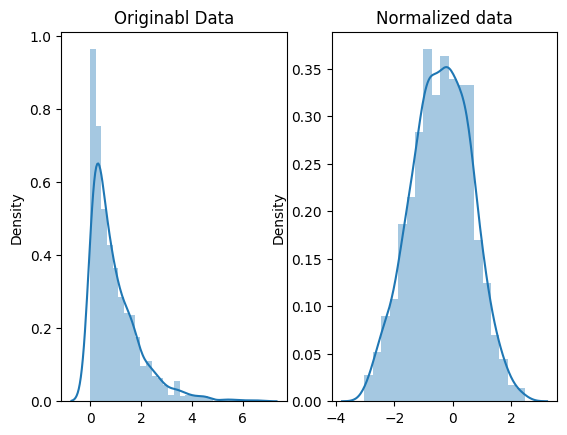

In [ ]:
# plot both together to compare
fig, ax=plt.subplots(1,2)

sns.distplot(original_data, ax=ax[0])
ax[0].set_title("Originabl Data")

sns.distplot(normalized_data[0], ax=ax[1])
ax[1].set_title("Normalized data")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

standerdized_data = StandardScaler().fit_transform(original_data.reshape(1, -1))

In [ ]:
standerdized_data

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

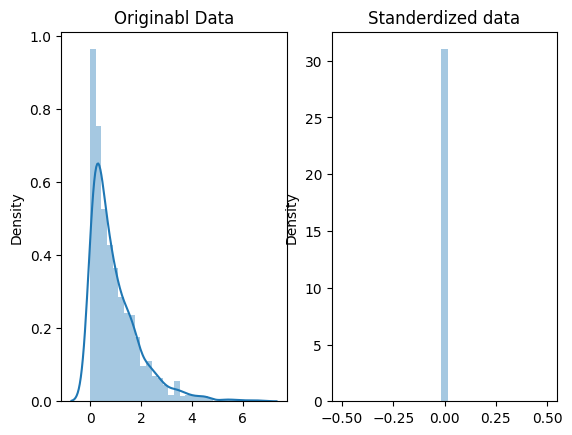

In [ ]:
# plot both together to compare
fig, ax=plt.subplots(1,2)

sns.distplot(original_data, ax=ax[0])
ax[0].set_title("Originabl Data")

sns.distplot(standerdized_data, ax=ax[1])
ax[1].set_title("Standerdized data")
plt.show()

In [ ]:
import seaborn as sns

# Load the dataset as a DataFrame
df = sns.load_dataset('iris')

# View the first 5 rows
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
df['species'].value_counts('setosa')

,proportion
species,
setosa,0.333333
versicolor,0.333333
virginica,0.333333


In [ ]:
# Assuming your DataFrame is named 'df'
setosa_count = len(df[df['species'] == 'setosa'])
print(f"There are {setosa_count} Setosa flowers.")

There are 50 Setosa flowers.


In [ ]:
df[df['species'] == 'setosa'].value_counts()

sepal_length  sepal_width  petal_length  petal_width  species
4.3           3.0          1.1           0.1          setosa     1
4.4           2.9          1.4           0.2          setosa     1
              3.0          1.3           0.2          setosa     1
              3.2          1.3           0.2          setosa     1
4.5           2.3          1.3           0.3          setosa     1
4.6           3.1          1.5           0.2          setosa     1
              3.2          1.4           0.2          setosa     1
              3.4          1.4           0.3          setosa     1
              3.6          1.0           0.2          setosa     1
4.7           3.2          1.3           0.2          setosa     1
                           1.6           0.2          setosa     1
4.8           3.0          1.4           0.1          setosa     1
                                         0.3          setosa     1
              3.1          1.6           0.2          setosa     1
              3.4          1.6           0.2          setosa     1
                           1.9           0.2          setosa     1
4.9           3.0          1.4           0.2          setosa     1
              3.1          1.5           0.1          setosa     1
                                         0.2          setosa     1
              3.6          1.4           0.1          setosa     1
5.0           3.0          1.6           0.2          setosa     1
              3.2          1.2           0.2          setosa     1
              3.3          1.4           0.2          setosa     1
              3.4          1.5           0.2          setosa     1
                           1.6           0.4          setosa     1
              3.5          1.3           0.3          setosa     1
                           1.6           0.6          setosa     1
              3.6          1.4           0.2          setosa     1
5.1           3.3          1.7           0.5          setosa     1
              3.4          1.5           0.2          setosa     1
              3.5          1.4           0.2          setosa     1
                                         0.3          setosa     1
              3.7          1.5           0.4          setosa     1
              3.8          1.5           0.3          setosa     1
                           1.6           0.2          setosa     1
                           1.9           0.4          setosa     1
5.2           3.4          1.4           0.2          setosa     1
              3.5          1.5           0.2          setosa     1
              4.1          1.5           0.1          setosa     1
5.3           3.7          1.5           0.2          setosa     1
5.4           3.4          1.5           0.4          setosa     1
                           1.7           0.2          setosa     1
              3.7          1.5           0.2          setosa     1
              3.9          1.3           0.4          setosa     1
                           1.7           0.4          setosa     1
5.5           3.5          1.3           0.2          setosa     1
              4.2          1.4           0.2          setosa     1
5.7           3.8          1.7           0.3          setosa     1
              4.4          1.5           0.4          setosa     1
5.8           4.0          1.2           0.2          setosa     1
Name: count, dtype: int64

In [ ]:
from datetime import date

data = pd.DataFrame({'date':['01-01-2017',
                             '04-12-2008',
                             '23-06-1988',
                             '25-08-1999',
                             '20-02-1993',]})
data

,date
0,01-01-2017
1,04-12-2008
2,23-06-1988
3,25-08-1999
4,20-02-1993


In [ ]:
#Transform string to date
data['date'] = pd.to_datetime(data.date, format="%d-%m-%Y")

data

,date
0,2017-01-01
1,2008-12-04
2,1988-06-23
3,1999-08-25
4,1993-02-20


In [ ]:
data['date'].dt.year

,date
0,2017
1,2008
2,1988
3,1999
4,1993


In [ ]:
data['date'].dt.month

,date
0,1
1,12
2,6
3,8
4,2


In [ ]:
data['date'].dt.day

,date
0,1
1,4
2,23
3,25
4,20


In [ ]:
data.sort_values('date')  # ✅ chronological order

,date
2,1988-06-23
4,1993-02-20
3,1999-08-25
1,2008-12-04
0,2017-01-01


In [ ]:
data['year'] = data['date'].dt.year

data

,date,year
0,2017-01-01,2017
1,2008-12-04,2008
2,1988-06-23,1988
3,1999-08-25,1999
4,1993-02-20,1993


In [ ]:
#Extracting Month
data['month'] = data['date'].dt.month

data

,date,year,month
0,2017-01-01,2017,1
1,2008-12-04,2008,12
2,1988-06-23,1988,6
3,1999-08-25,1999,8
4,1993-02-20,1993,2


In [ ]:
#Extracting passed years since the date
data['passed_years'] = date.today().year - data['date'].dt.year

data

,date,year,month,passed_years
0,2017-01-01,2017,1,9
1,2008-12-04,2008,12,18
2,1988-06-23,1988,6,38
3,1999-08-25,1999,8,27
4,1993-02-20,1993,2,33


In [ ]:
from datetime import date

today = pd.to_datetime(date.today())

data['passed_months'] = (
    (today.year - data['date'].dt.year) * 12 +
    (today.month - data['date'].dt.month)
)
data

,date,year,month,passed_years,passed_months
0,2017-01-01,2017,1,9,108
1,2008-12-04,2008,12,18,205
2,1988-06-23,1988,6,38,451
3,1999-08-25,1999,8,27,317
4,1993-02-20,1993,2,33,395


In [ ]:
data

,date,year,month,passed_years,passed_months
0,2017-01-01,2017,1,9,108
1,2008-12-04,2008,12,18,205
2,1988-06-23,1988,6,38,451
3,1999-08-25,1999,8,27,317
4,1993-02-20,1993,2,33,395


In [ ]:
data.drop(['passed_months'], axis=1, inplace=True)

In [ ]:
data

,date,year,month,passed_years
0,2017-01-01,2017,1,9
1,2008-12-04,2008,12,18
2,1988-06-23,1988,6,38
3,1999-08-25,1999,8,27
4,1993-02-20,1993,2,33


In [ ]:
#Extracting the weekday name of the date
data['day_name'] = data['date'].dt.day_name()

data

,date,year,month,passed_years,day_name
0,2017-01-01,2017,1,9,Sunday
1,2008-12-04,2008,12,18,Thursday
2,1988-06-23,1988,6,38,Thursday
3,1999-08-25,1999,8,27,Wednesday
4,1993-02-20,1993,2,33,Saturday
